The Data

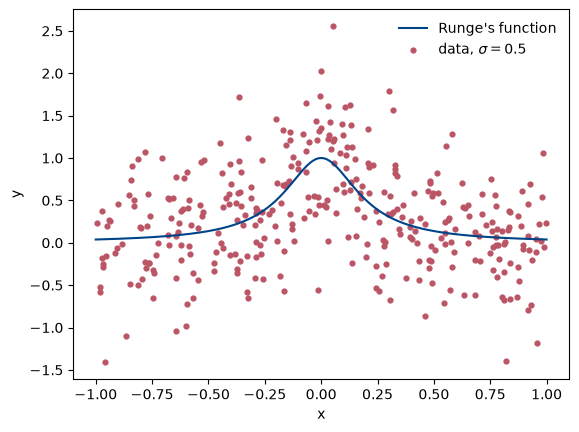

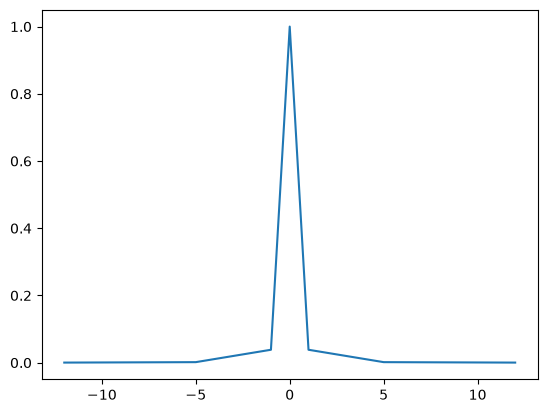

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
sigma = 0.5                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, n)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

x2 = np.array([-12,-5,-1, 0, 1, 5, 12])
plt.plot(x2, runge(x2))
plt.show()

Part a) OLS for the Runge function

In [ ]:
# Your code for part a) here
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

maxdeg = 15
deg_V = np.arange(maxdeg + 1)
MSE_V = []
R2_V = []
Parameter_V = []
Prediction_V = []

# No reason to scale and normalise for OLS! Why?
for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Konstantkolonnen skal fortsatt være lik 1.
    mean[0] = 0.0
    std[0] = 1.0

    X_train_c = (X_train - mean) / std
    X_test_c = (X_test - mean) / std

    theta = np.linalg.pinv(X_train_c) @ y_train
    Parameter_V.append(theta)

    # Bruk treningsmodellens normalisering for hver grads prediksjonskurve.

    X_plot = design_matrix(xx, degree)
    X_plot_scaled = (X_plot - mean) / std
    Prediction_V.append(X_plot_scaled @ theta)

    y_predict = X_test_c @ theta
    mse = np.mean((y_test - y_predict)**2)
    MSE_V.append(mse)

    y_mean = np.mean(y_test)
    R2 = 1 - (np.sum((y_test - y_predict)**2))/(np.sum((y_test - y_mean)**2))
    R2_V.append(R2)

OLS_5D_theta = Parameter_V[5]



[ 0.3086104   0.07533971 -0.71624571 -0.34727899  0.53006476  0.26434645]


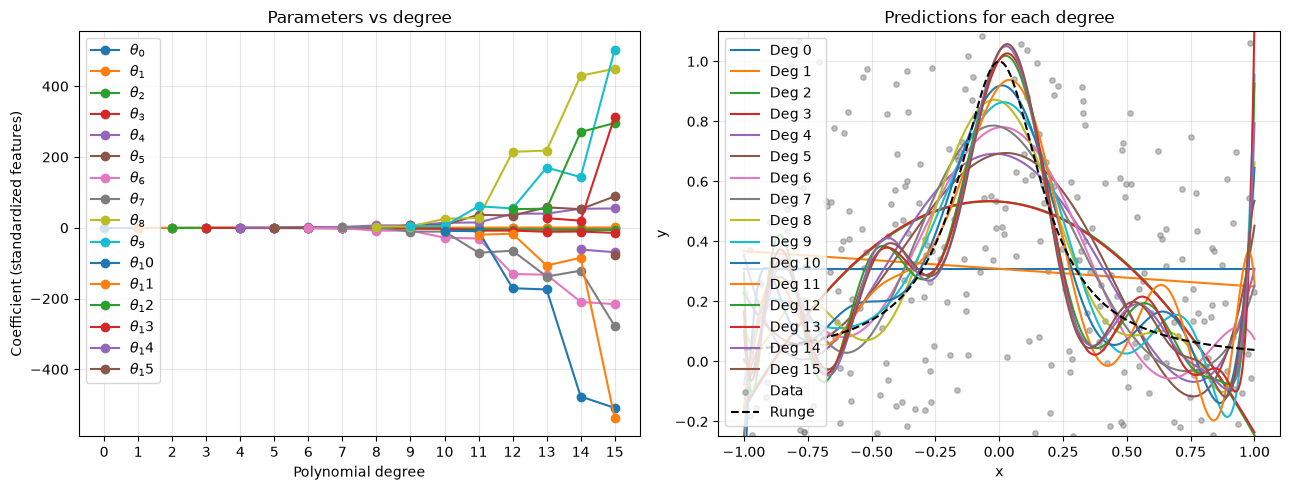

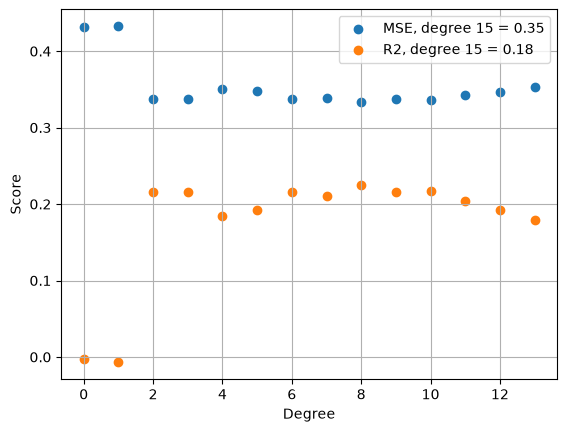

In [3]:
fig, (ax_parameters, ax_predictions) = plt.subplots(1, 2, figsize=(13, 5))

# Grad d har d + 1 parametre. NaN markerer parametre modellen ikke har.
parameters = np.full((maxdeg + 1, maxdeg + 1), np.nan)
for degree, theta in enumerate(Parameter_V):
    parameters[degree, :len(theta)] = theta
    ax_predictions.plot(xx, Prediction_V[degree], label=f"Deg {degree}")

for j in range(maxdeg + 1):
    ax_parameters.plot(deg_V, parameters[:, j], marker="o", label=rf"$\theta_{j}$")

ax_parameters.set(title="Parameters vs degree", xlabel="Polynomial degree",
                  ylabel="Coefficient (standardized features)")
ax_parameters.set_xticks(deg_V)
ax_parameters.legend()
ax_parameters.grid(alpha=0.3)

ax_predictions.scatter(x, y, s=15, color="gray", alpha=0.5, label="Data")
ax_predictions.plot(xx, runge(xx), "k--", label="Runge")
ax_predictions.set(title="Predictions for each degree", xlabel="x", ylabel="y")
ax_predictions.legend()
ax_predictions.grid(alpha=0.3)
fig.tight_layout()
plt.ylim(-0.25,1.1)
plt.show()
#  R2 og MSE
plt.scatter(deg_V[0:-2], MSE_V[0:-2], label = f"MSE, degree {maxdeg} = {MSE_V[-1]:.2f}")
plt.scatter(deg_V[0:-2], R2_V[0:-2], label = f"R2, degree {maxdeg} = {R2_V[-1]:.2f}")
plt.xlabel("Degree")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

Part b): Adding Ridge Regression for the Runge function

In [34]:
lambdas = [1e-2, 1e-1, 0.5, 1.0, 1e1]
MSE_grid = np.zeros((maxdeg + 1, len(lambdas)))
R2_grid = np.zeros((maxdeg + 1, len(lambdas)))

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    # Beregn gjennomsnitt og standardavvik fra treningsdata
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Behold konstantkolonnen: (1 - 0) / 1 = 1
    mean[0] = 0
    std[0] = 1

    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std
    # Trenger ikke sentrere y da design matrisen inneholder intercept

    #X_train_norm = X_train 
    #X_test_norm = X_test


    for i, lmb in enumerate(lambdas):
        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke at intercept skal bli straffet av Ridge
        
        theta = np.linalg.pinv((X_train_norm).T @ (X_train_norm) + lmb*I) @ (X_train_norm).T @ y_train
        if degree == 5 and lmb == 1e-2:
            #print(theta)
            Ridge_5D_theta = theta
        
        y_predict = X_test_norm @ theta
        mse = np.mean((y_test - y_predict)**2)
        #MSE_V.append(mse)

        y_predict = X_test_norm @ theta 
        MSE_grid[degree, i] = np.mean((y_test - y_predict)**2)
        y_mean = np.mean(y_test)
        R2_grid[degree, i] = 1 - np.sum((y_test - y_predict)**2) / np.sum((y_test - y_mean)**2)

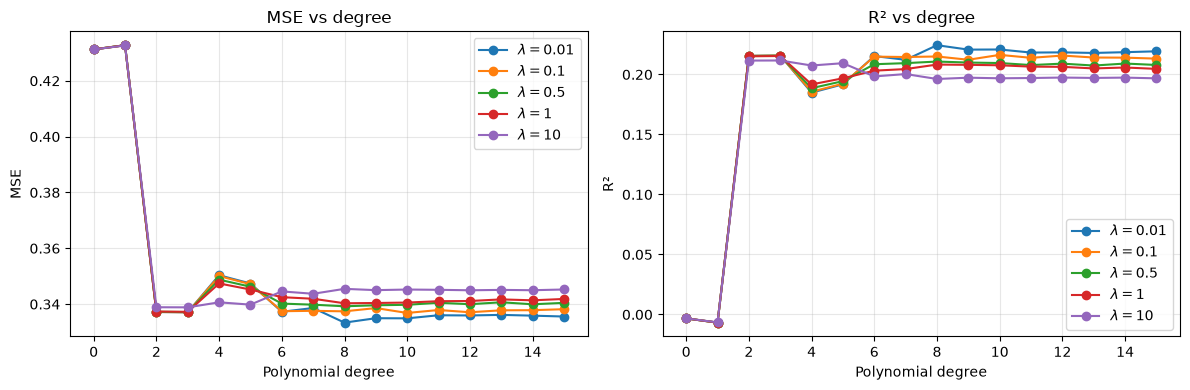

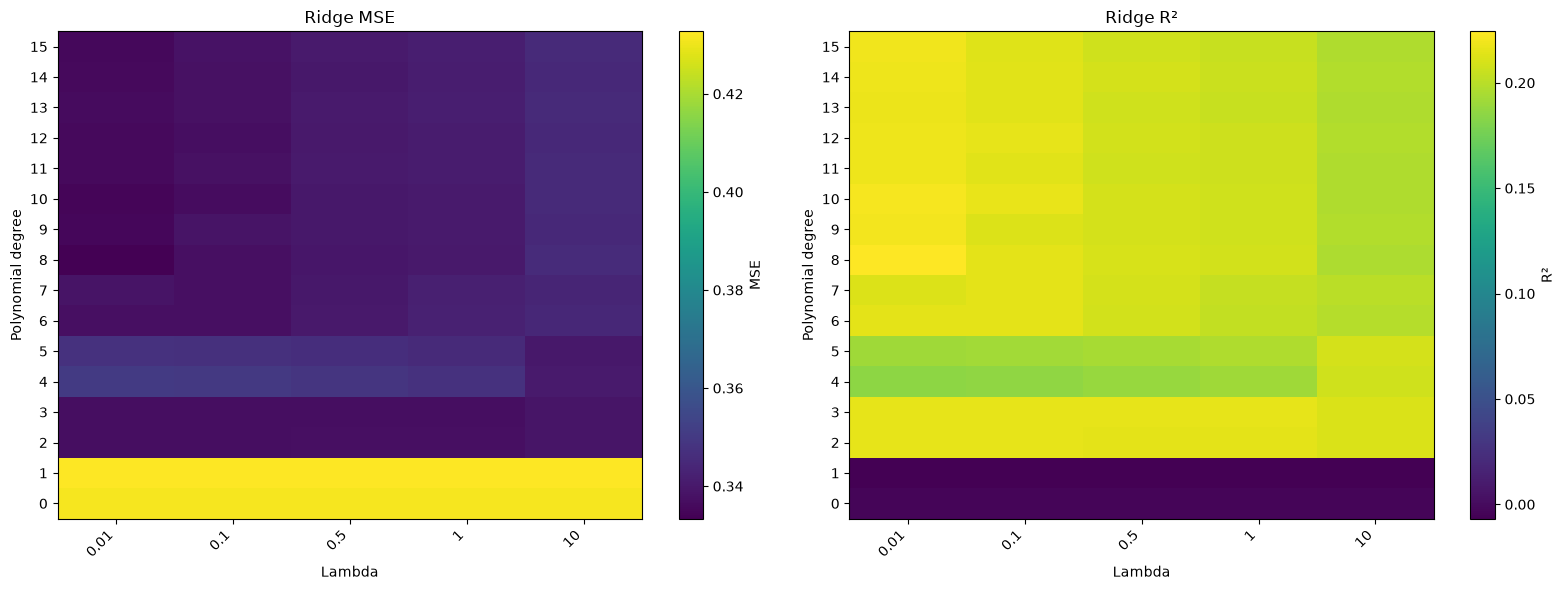

In [5]:
# b) plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, lam in enumerate(lambdas):
    axes[0].plot(deg_V, MSE_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")
    axes[1].plot(deg_V, R2_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs degree")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("R²")
axes[1].set_title("R² vs degree")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE heatmap
im1 = axes[0].imshow(MSE_grid, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Ridge MSE")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Polynomial degree")
axes[0].set_xticks(np.arange(len(lambdas)))
axes[0].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[0].set_yticks(np.arange(maxdeg + 1))
axes[0].set_yticklabels(deg_V)
fig.colorbar(im1, ax=axes[0], label="MSE")

# R² heatmap
im2 = axes[1].imshow(R2_grid, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Ridge R²")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Polynomial degree")
axes[1].set_xticks(np.arange(len(lambdas)))
axes[1].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[1].set_yticks(np.arange(maxdeg + 1))
axes[1].set_yticklabels(deg_V)
fig.colorbar(im2, ax=axes[1], label="R²")

plt.tight_layout()
plt.show()

Part c): The bias-variance tradeoff and the bootstrap

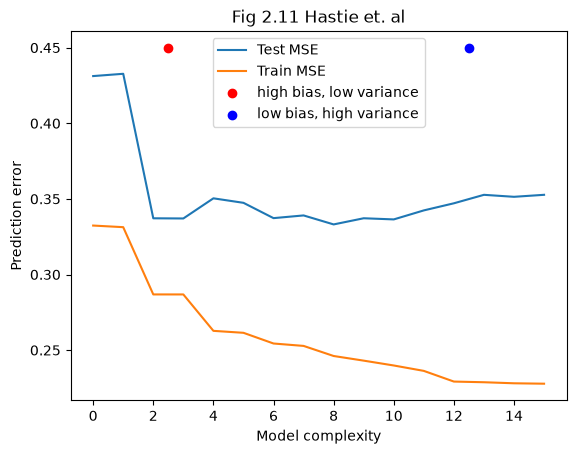

In [6]:
from sklearn.metrics import mean_squared_error
"""rng = np.random.default_rng(2026)
n = 350
sigma = 0.5        
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)
Her måtte jeg justere n sigma og degrees for å gjenskape figur 2.11
Disse nye verdiene ble så brukt for alle de andre programmene"""
#maxdeg = 20 # New maxdegree
#deg_V = np.arange(maxdeg + 1)
MSE_test = []
MSE_train = []

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    theta = np.linalg.pinv(X_train) @ y_train
    Parameter_V.append(theta)

    y_predict_test = X_test @ theta
    y_predict_train = X_train @ theta
    # Here i create the data for figure 2.11
    mse_test = mean_squared_error(y_test, y_predict_test)
    MSE_test.append(mse_test)
    mse_train = mean_squared_error(y_train, y_predict_train)
    MSE_train.append(mse_train)


plt.plot(deg_V, MSE_test, label = "Test MSE")
plt.plot(deg_V, MSE_train, label = "Train MSE")
plt.title("Fig 2.11 Hastie et. al")
plt.xlabel("Model complexity")
plt.ylabel("Prediction error")
plt.scatter(2.5, 0.45, color = "red", label = "high bias, low variance")
plt.scatter(12.5, 0.45, color = "blue",label = "low bias, high variance")
plt.legend()
plt.show()

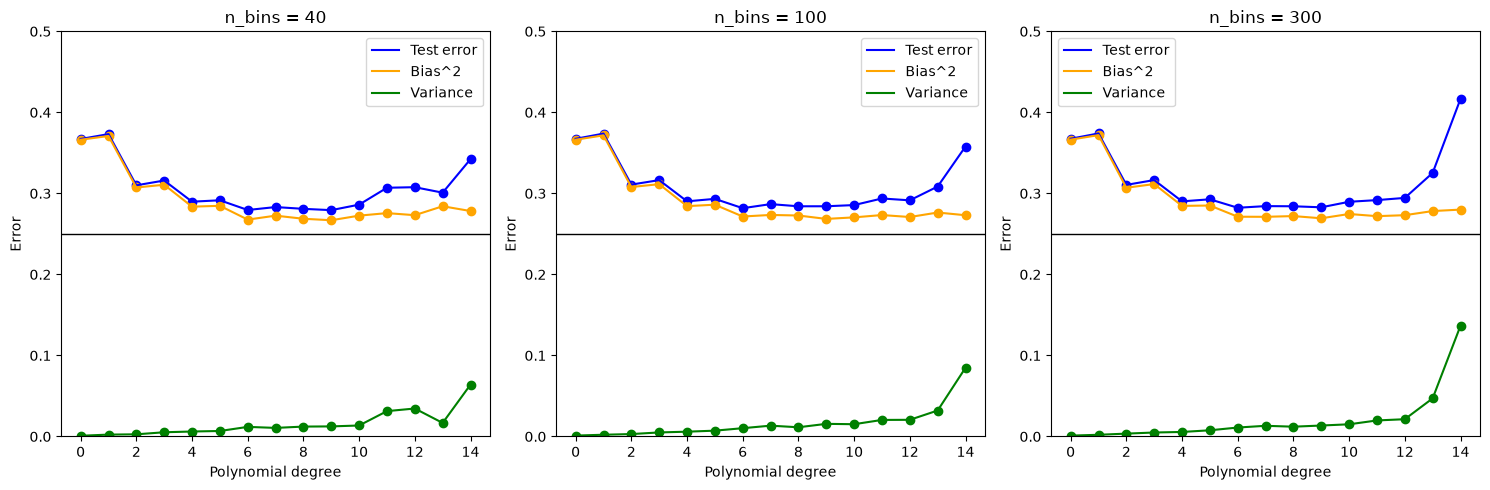

In [7]:
# Bootstrap cross-validation
from sklearn.utils import resample

n = 350
sigma = 0.5             # noise level fig 2.11
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

def bootstrap_bias_variance(n_bs, maxdeg):

    error = np.zeros(maxdeg)
    bias = np.zeros(maxdeg)
    variance = np.zeros(maxdeg)

    for degree in range(maxdeg):
        X = design_matrix(x, degree)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=2026
        )
        y_pred = np.zeros((y_test.shape[0], n_bs))
        for i in range(n_bs):
            X_bs, y_bs = resample(X_train, y_train)
            theta = np.linalg.pinv(X_bs) @ y_bs

            y_pred[:, i] = X_test @ theta

        # Compare each test target with every bootstrap prediction for that point.
        error[degree] = np.mean((y_test[:, None] - y_pred)**2)
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1))
    
    return error, bias, variance 
# maxdeg = 20 as in 2.11
# 40 bins
error40, bias40, variance40 = bootstrap_bias_variance(n_bs=40, maxdeg=15)
# 100 bins
error100, bias100, variance100 = bootstrap_bias_variance(n_bs=100, maxdeg=15)
# 300 bins
error300, bias300, variance300 = bootstrap_bias_variance(n_bs=300,maxdeg=15)

degree_vec = range(15)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

results = [
    (error40, bias40, variance40, 40),
    (error100, bias100, variance100, 100),
    (error300, bias300, variance300, 300)
]

for i, (error, bias, variance, n) in enumerate(results):

    ax[i].plot(degree_vec, error, label="Test error", color="blue")
    ax[i].scatter(degree_vec, error, color="blue")

    ax[i].plot(degree_vec, bias, label="Bias^2", color="orange")
    ax[i].scatter(degree_vec, bias, color="orange")

    ax[i].plot(degree_vec, variance, label="Variance", color="green")
    ax[i].scatter(degree_vec, variance, color="green")

    ax[i].axhline(y=sigma**2, color="black", linestyle="-", linewidth=1)

    ax[i].set_title(f"n_bins = {n}")
    ax[i].set_xlabel("Polynomial degree")
    ax[i].set_ylabel("Error")
    ax[i].legend()
    ax[i].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

Part d): Cross-Validation as a resampling technique

OLS, k=5: maximum absolute MSE difference = 1.191e-14
Ridge, k=5, lambda=0.01: maximum absolute MSE difference = 4.241e-14
Ridge, k=5, lambda=0.1: maximum absolute MSE difference = 3.025e-15
Ridge, k=5, lambda=0.5: maximum absolute MSE difference = 8.882e-16
Ridge, k=5, lambda=1: maximum absolute MSE difference = 6.661e-16
Ridge, k=5, lambda=10: maximum absolute MSE difference = 1.665e-16
OLS, k=10: maximum absolute MSE difference = 8.216e-15
Ridge, k=10, lambda=0.01: maximum absolute MSE difference = 2.701e-14
Ridge, k=10, lambda=0.1: maximum absolute MSE difference = 3.109e-15
Ridge, k=10, lambda=0.5: maximum absolute MSE difference = 9.714e-16
Ridge, k=10, lambda=1: maximum absolute MSE difference = 7.216e-16
Ridge, k=10, lambda=10: maximum absolute MSE difference = 1.110e-16


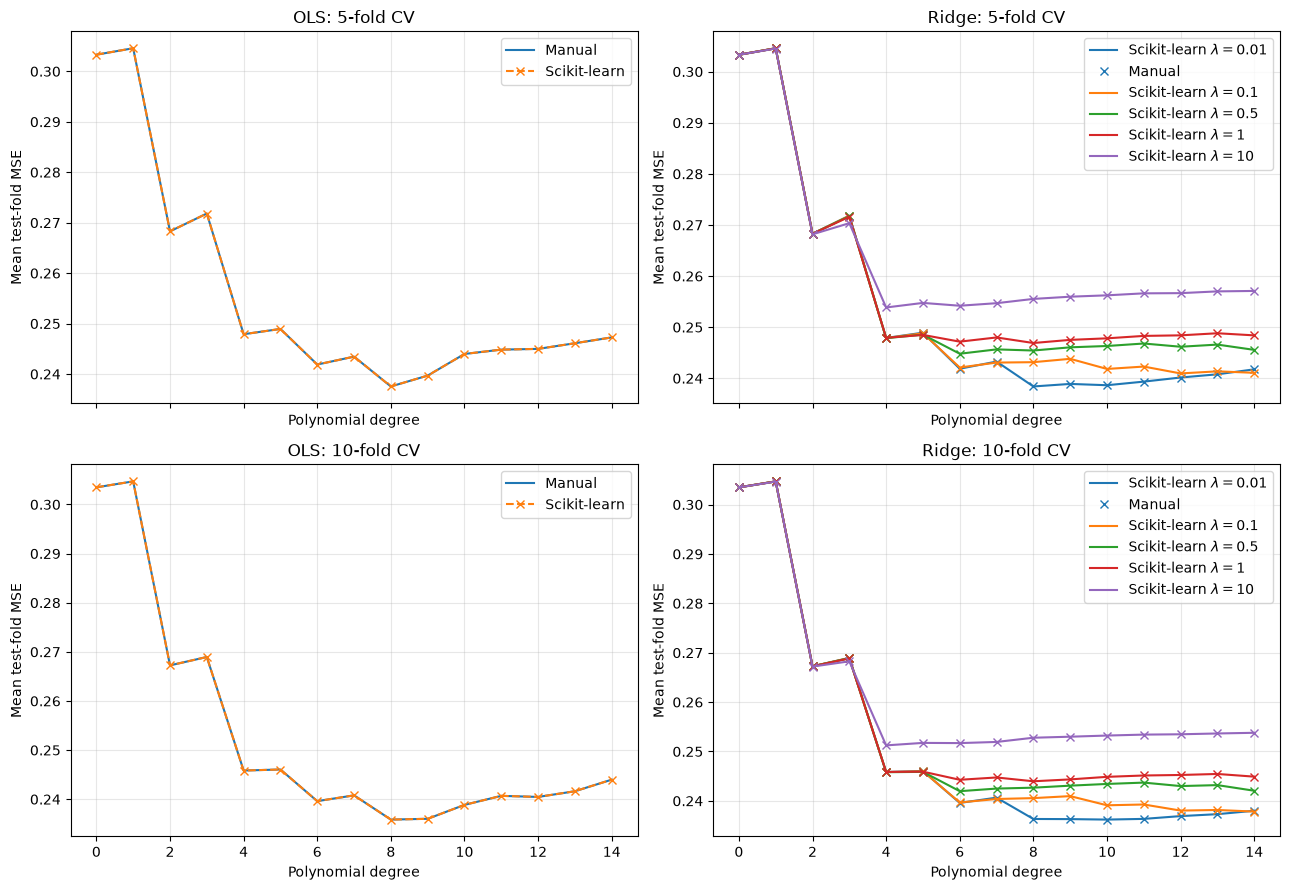

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Your code for part d) here
# No reason to scale for OLS regression.
def kfold_CV_OLS(folds, degree):
    X = design_matrix(x, degree)

    kfold = KFold(
        n_splits=folds,
        shuffle=True,
        random_state=2026
    )
    
    fold_mse = []
    for train_index, test_index in kfold.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]


        theta = np.linalg.pinv(x_train) @ y_train
        y_pred = x_test @ theta
        mse = np.mean((y_test - y_pred) ** 2)
        fold_mse.append(mse)

    mse_mean = np.mean(fold_mse)
    mse_std = np.std(fold_mse, ddof=1)
    return mse_mean, mse_std


def ridge_kfold(k, deg, lmb):
    X = design_matrix(x, deg)
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    score_KFold = []
    
    for train_ind, test_ind in kfold.split(X):
        x_train, x_test = X[train_ind], X[test_ind]
        y_train, y_test = y[train_ind], y[test_ind]

        # Skalering
        # Beregn gjennomsnitt og standardavvik fra treningsdata
        mean = x_train.mean(axis=0)
        std = x_train.std(axis=0)

        # Behold konstantkolonnen intercept: (1 - 0) / 1 = 1
        mean[0] = 0
        std[0] = 1

        X_train_norm = (x_train - mean) / std
        X_test_norm = (x_test - mean) / std
        # Trenger ikke sentrere y da design matrisen inneholder intercept

        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke straffe intercept i Ridge regresjon

        theta = np.linalg.pinv((X_train_norm).T @ (X_train_norm) + lmb*I) @ (X_train_norm).T @ y_train

        y_predict = X_test_norm @ theta 
        mse = np.mean((y_test - y_predict)**2)
        score_KFold.append(mse)
    mse_Kfold = np.mean(score_KFold)
    mse_std = np.std(score_KFold, ddof=1)
    return mse_Kfold, mse_std


def sklearn_kfold(folds, degree, lmb=None):
    X = design_matrix(x, degree)
    cv = KFold(n_splits=folds, shuffle=True, random_state=2026)

    if lmb is None:
        # X already includes the constant column.
        model = LinearRegression(fit_intercept=False)
    else:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=lmb, fit_intercept=True, solver="svd")
        )

    fold_mse = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring="neg_mean_squared_error",
        error_score="raise"
    )

    return fold_mse.mean(), fold_mse.std(ddof=1)


degrees = np.arange(15)
lambdas = [1e-2, 1e-1,0.5, 1.0, 1e1]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for row, folds in enumerate([5, 10]):
    # OLS
    manual = np.array([
        kfold_CV_OLS(folds, degree)[0]
        for degree in degrees
    ])
    sklearn_mse = np.array([
        sklearn_kfold(folds, degree)[0]
        for degree in degrees
    ])

    ax = axes[row, 0]
    ax.plot(degrees, manual, label="Manual")
    ax.plot(degrees, sklearn_mse, "x--", label="Scikit-learn")
    ax.set_title(f"OLS: {folds}-fold CV")
    print(
        f"OLS, k={folds}: maximum absolute MSE difference = "
        f"{np.max(np.abs(manual - sklearn_mse)):.3e}"
    )

    # Ridge: one curve per lambda
    ax = axes[row, 1]
    for lmb in lambdas:
        manual = np.array([
            ridge_kfold(folds, degree, lmb)[0]
            for degree in degrees
        ])
        sklearn_mse = np.array([
            sklearn_kfold(folds, degree, lmb)[0]
            for degree in degrees
        ])

        line, = ax.plot(
            degrees, sklearn_mse,
            label=rf"Scikit-learn $\lambda={lmb:g}$"
        )
        ax.plot(
            degrees, manual, "x", color=line.get_color(),
            label="Manual" if lmb == lambdas[0] else "_nolegend_"
        )
        print(
            f"Ridge, k={folds}, lambda={lmb:g}: "
            f"maximum absolute MSE difference = "
            f"{np.max(np.abs(manual - sklearn_mse)):.3e}"
        )

    ax.set_title(f"Ridge: {folds}-fold CV")

for ax in axes.flat:
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Mean test-fold MSE")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Part e)

In [33]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda): # [1:] vil ikke straffe intercept
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
print("best eta of OLS = ", 2.0/ (np.linalg.eigvalsh(H).max() + np.linalg.eigvalsh(H).min()))

OLS   max |AD - analytic| = 3.0531133177191805e-16
Ridge max |AD - analytic| = 3.0531133177191805e-16
eta_max for OLS  = 0.8384333865289776
best eta of OLS =  0.8379849361048061


In [ ]:
print(OLS_5D_theta)
print(Ridge_5D_theta)

num_iters = 1000
tol = 1e-8

# Nå skal jeg gjennomføre Gradient Descent



[ 0.3086104   0.07533971 -0.71624571 -0.34727899  0.53006476  0.26434645]
[ 0.22571597  0.24912073 -0.64819419 -0.43448021  0.50870303  0.21510467]
